<a href="https://colab.research.google.com/github/gautamthampy/CMPE256-Group10/blob/collaborative_filtering_v1/recommender_system_grp10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**1. Data loading**

In [46]:
data = {}
with open("train-2.txt") as f:
  for line in f:
    parts = line.strip().split()
    if not parts:
      continue
    user = parts[0]
    items = parts[1:]
    data[user] = items

print(f"Number of users = {len(data.keys())}")

Number of users = 52643


**2. Data analysis and visualization**

In [47]:
import numpy as np

items_per_user = [len(items) for items in data.values()]

print("Average items per user:", np.mean(items_per_user))
print("Median items per user:", np.median(items_per_user))
print("Max items for any user:", np.max(items_per_user))
print("Min items for any user:", np.min(items_per_user))

Average items per user: 45.22405637976559
Median items per user: 26.0
Max items for any user: 10682
Min items for any user: 16


In [48]:
from collections import Counter

item_counts = Counter()

for items in data.values():
    item_counts.update(items)

print("Total unique items:", len(item_counts))
print("Average users per item:", np.mean(list(item_counts.values())))
print("Median users per item:", np.median(list(item_counts.values())))
print("Max users for any item:", max(item_counts.values()))
print("Items with only one user:", sum(1 for x in item_counts.values() if x == 1))


Total unique items: 91599
Average users per item: 25.990785925610542
Median users per item: 15.0
Max users for any item: 1741
Items with only one user: 781


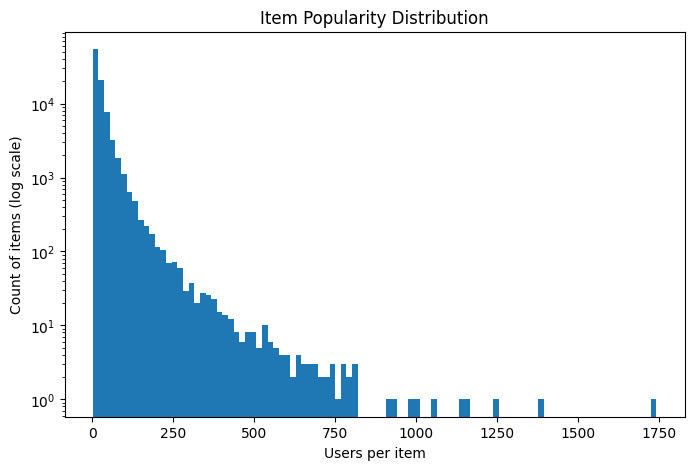

In [49]:
import matplotlib.pyplot as plt

# distribution of item popularity
item_freqs = np.array(list(item_counts.values()))

plt.figure(figsize=(8,5))
plt.hist(item_freqs, bins=100, log=True)
plt.xlabel("Users per item")
plt.ylabel("Count of items (log scale)")
plt.title("Item Popularity Distribution")
plt.show()


**3. Popularity baseline**

In [50]:
import random

random.seed(42)

train_data = {}
val_items = {}

for user, items in data.items():
    held_out = random.choice(items)
    train_items = [it for it in items if it != held_out]

    train_data[user] = train_items
    val_items[user] = held_out

print("Train users:", len(train_data))
print("Val users:", len(val_items))


Train users: 52643
Val users: 52643


In [51]:
from collections import Counter

pop_counts = Counter()

for items in train_data.values():
    pop_counts.update(items)

print("Unique items in train:", len(pop_counts))
print("Most common 5:", pop_counts.most_common(5))


Unique items in train: 91569
Most common 5: [('896', 1681), ('43756', 1352), ('7897', 1207), ('36454', 1123), ('36477', 1098)]


In [52]:
import math

def ndcg_at_k_single(recommended, true_item, k=20):
    # recommended: list of item_ids in ranked order
    # true_item: the held-out item_id
    try:
        rank = recommended.index(true_item)
    except ValueError:
        return 0.0

    if rank >= k:
        return 0.0

    return 1.0 / math.log2(rank + 2)


In [53]:
all_items_by_pop = [it for it, _ in pop_counts.most_common()]

def recommend_popularity(user, k=20):
    seen = set(train_data[user])
    recs = []
    for it in all_items_by_pop:
        if it in seen:
            continue
        recs.append(it)
        if len(recs) == k:
            break
    return recs


In [54]:
def mean_ndcg_at_20_popularity():
    scores = []
    for user, true_item in val_items.items():
        recs = recommend_popularity(user, k=20)
        score = ndcg_at_k_single(recs, true_item, k=20)
        scores.append(score)
    return sum(scores) / len(scores)

pop_ndcg = mean_ndcg_at_20_popularity()
print("Popularity NDCG@20:", pop_ndcg)


Popularity NDCG@20: 0.0047054802836267616


**4. item based collaborative filtering**

In [55]:
from collections import Counter
import itertools
from collections import defaultdict

def build_covisit_model(data, pop_counts, max_items_per_user=40, max_neighbors=200):
    pop_rank = {item: rank for rank, (item, _) in enumerate(pop_counts.most_common())}

    MAX_ITEMS_PER_USER = max_items_per_user

    trimmed_train = {}
    for user, items in data.items():
        # sort this user's items by global popularity (most common first)
        items_sorted = sorted(items, key=lambda it: pop_rank[it])
        trimmed_train[user] = items_sorted[:MAX_ITEMS_PER_USER]

    cooc = defaultdict(lambda: defaultdict(int))

    for items in trimmed_train.values():
        uniq_items = list(set(items))
        for i, j in itertools.combinations(uniq_items, 2):
            cooc[i][j] += 1
            cooc[j][i] += 1

    MAX_NEIGHBORS = max_neighbors

    for i, neighbors in list(cooc.items()):
        if len(neighbors) > MAX_NEIGHBORS:
            top_neighbors = sorted(neighbors.items(), key=lambda x: x[1], reverse=True)[:MAX_NEIGHBORS]
            cooc[i] = dict(top_neighbors)

    return cooc, pop_rank

In [56]:
def recommend_cooc(cooc, data, pop_counts, user, alpha, k=20):
    seen = set(data[user])
    scores = defaultdict(float)

    for i in seen:
        for j, c in cooc[i].items():
            if j in seen:
                continue
            scores[j] += c / math.sqrt(pop_counts[i] * pop_counts[j])
            # scores[j] += c / math.log2(2 + pop_counts[j])

    if not scores:
        # fallback to popularity
        return recommend_popularity(user, k=k)

    ALPHA = alpha

    for j in list(scores.keys()):
        scores[j] += ALPHA * item_bias_z(j)

    # sort by score, highest first
    ranked = sorted(scores.items(), key=lambda x: x[1], reverse=True)
    recs = [it for it, _ in ranked[:k]]
    return recs


In [57]:
def mean_ndcg_at_20_cooc(cooc, alpha):
    scores = []
    for user, true_item in val_items.items():
        recs = recommend_cooc(cooc, train_data, pop_counts, user, alpha, k=20)
        score = ndcg_at_k_single(recs, true_item, k=20)
        scores.append(score)
    return sum(scores) / len(scores)


In [58]:
# for m in [20, 40, 60, 80, 100]:
#     cooc_tuned, pop_rank_tuned = build_covisit_model(
#         train_data,
#         pop_counts,
#         max_items_per_user=m,
#         max_neighbors=200
#     )
#     ndcg = mean_ndcg_at_20_cooc(cooc_tuned)
#     print("max_items_per_user =", m, " -> NDCG@20 =", ndcg)

In [59]:
# for m in [85, 90, 95]:
#     cooc_tuned, pop_rank_tuned = build_covisit_model(
#         train_data,
#         pop_counts,
#         max_items_per_user=m,
#         max_neighbors=400
#     )
#     ndcg = mean_ndcg_at_20_cooc(cooc_tuned)
#     print("max_items_per_user =", m, " -> NDCG@20 =", ndcg)

In [60]:
# for m in [100, 250, 400]:
#     cooc_tuned, pop_rank_tuned = build_covisit_model(
#         train_data,
#         pop_counts,
#         max_items_per_user=80,
#         max_neighbors=m
#     )
#     ndcg = mean_ndcg_at_20_cooc(cooc_tuned)
#     print("max_neighbors =", m, " -> NDCG@20 =", ndcg)

In [61]:
# cooc_tuned, pop_rank_tuned = build_covisit_model(
#   train_data,
#   pop_counts,
#   max_items_per_user=80,
#   max_neighbors=400
# )
# ndcg = mean_ndcg_at_20_cooc(cooc_tuned)
# print("NDCG@20 =", ndcg)

In [62]:
# cooc_tuned, pop_rank_tuned = build_covisit_model(
#   train_data,
#   pop_counts,
#   max_items_per_user=80,
#   max_neighbors=400
# )
# ndcg = mean_ndcg_at_20_cooc(cooc_tuned)
# print("NDCG@20 =", ndcg)

**Adding popularity bias**

In [63]:
import math

mean_pop = np.mean(list(pop_counts.values()))
std_pop  = np.std(list(pop_counts.values()))

def item_bias_z(j):
    return (pop_counts[j] - mean_pop) / (std_pop + 1e-8)


In [64]:
# cooc_tuned, pop_rank_tuned = build_covisit_model(
#   train_data,
#   pop_counts,
#   max_items_per_user=80,
#   max_neighbors=400
# )
# for alpha in [-0.3, -0.1, 0.0, 0.1, 0.3]:
#     ndcg = mean_ndcg_at_20_cooc(cooc_tuned, alpha)
#     print("ALPHA =", alpha, "-> NDCG@20 =", ndcg)

## Matrix Factorization

In [97]:
users = list(data.keys())
user_to_idx = {u: idx for idx, u in enumerate(users)}

all_items = sorted({it for items in data.values() for it in items})
item_to_idx = {it: idx for idx, it in enumerate(all_items)}

n_users = len(users)      # 52643
n_items = len(all_items)  # 91599

print(n_users)
print(n_items)


52643
91599


In [98]:
import scipy.sparse as sp

rows_tr, cols_tr, vals_tr = [], [], []

for user, items in train_data.items():
    u = user_to_idx[user]
    for item in items:
        i = item_to_idx[item]
        rows_tr.append(u)   # row = user
        cols_tr.append(i)   # col = item
        vals_tr.append(1)

X_train = sp.csr_matrix((vals_tr, (rows_tr, cols_tr)),
                        shape=(n_users, n_items))

print("X_train shape:", X_train.shape)  # MUST be (52643, 91599)
print("Train nnz:", X_train.nnz)


X_train shape: (52643, 91599)
Train nnz: 2328087


In [99]:
import implicit

# implicit expects item-user matrix
item_users = X_train.tocsr()   # shape: (n_items, n_users) = (91599, 52643)
print("item_users_shape:", item_users.shape)


bpr_model = implicit.bpr.BayesianPersonalizedRanking(
    factors=64,
    learning_rate=0.05,
    regularization=0.01,
    iterations=50,
    random_state=42,
)

bpr_model.fit(item_users)

item_users_shape: (52643, 91599)


100%|██████████| 50/50 [00:03<00:00, 14.85it/s, train_auc=97.85%, skipped=0.45%]


In [100]:
print("user_factors:", bpr_model.user_factors.shape)
print("item_factors:", bpr_model.item_factors.shape)


user_factors: (52643, 65)
item_factors: (91599, 65)


In [101]:
user_items = item_users.T.tocsr()
print(user_items.shape)    # this is just X_train again
# shape: (n_users, n_items) = (52643, 91599)


(91599, 52643)


In [102]:
idx_to_item = np.array(all_items)   # item_idx -> original item_id



In [103]:
def recommend_bpr(user, k=20):
    u = user_to_idx[user]           # 0 <= u < n_users

    # get a 1 x n_items sparse row for THIS user
    user_row = user_items[u]

    rec_item_indices, scores = bpr_model.recommend(
        userid=u,                   # used to pick user_factors[u]
        user_items=user_row,        # shape (1, n_items) as required
        N=k,
        filter_already_liked_items=True,
    )

    rec_items = [idx_to_item[i] for i in rec_item_indices]
    return rec_items



In [104]:
def mean_ndcg_at_20_bpr():
    scores = []
    for user, true_item in val_items.items():
        recs = recommend_bpr(user, k=20)
        score = ndcg_at_k_single(recs, true_item, k=20)
        scores.append(score)
    return sum(scores) / len(scores)

bpr_ndcg = mean_ndcg_at_20_bpr()
print("BPR MF NDCG@20:", bpr_ndcg)


BPR MF NDCG@20: 0.014437257548587464


Combination

In [106]:
def covis_candidates(user, cooc, candidate_k=200):
    seen = set(train_data[user])
    scores = defaultdict(float)

    for i in seen:
        if i not in cooc:
            continue
        for j, c in cooc[i].items():
            if j in seen:
                continue
            # your current PMI-style scoring:
            scores[j] += c / math.sqrt(pop_counts[i] * pop_counts[j])

    if not scores:
        # fallback: use global popularity (maybe top candidate_k)
        return recommend_popularity(user, k=candidate_k)

    ranked = sorted(scores.items(), key=lambda x: x[1], reverse=True)
    # return both items and scores
    return ranked[:candidate_k]   # list of (item_id, covis_score)


In [107]:
def bpr_score(user, item_id):
    u = user_to_idx[user]
    i = item_to_idx[item_id]
    return float(np.dot(bpr_model.user_factors[u],
                        bpr_model.item_factors[i]))


In [108]:
def recommend_blend(user, cooc, lambda_, k=20, candidate_k=200):
    # 1) get candidates & co-vis scores
    candidates = covis_candidates(user, cooc, candidate_k=candidate_k)
    # candidates: list of (item_id, covis_score)

    final_scores = []
    for item_id, covis_score in candidates:
        try:
            bs = bpr_score(user, item_id)
        except KeyError:
            # item maybe missing in item_to_idx (should be rare)
            bs = 0.0
        score = covis_score + lambda_ * bs
        final_scores.append((item_id, score))

    # sort by blended score
    final_scores.sort(key=lambda x: x[1], reverse=True)

    # take top-k items
    rec_items = [it for it, _ in final_scores[:k]]
    return rec_items


In [109]:
def mean_ndcg_at_20_blend(cooc, lambda_, candidate_k=200):
    scores = []
    for user, true_item in val_items.items():
        recs = recommend_blend(user, cooc, lambda_, k=20, candidate_k=candidate_k)
        score = ndcg_at_k_single(recs, true_item, k=20)
        scores.append(score)
    return sum(scores) / len(scores)


In [110]:
cooc_tuned, pop_rank_tuned = build_covisit_model(
  train_data,
  pop_counts,
  max_items_per_user=80,
  max_neighbors=400
)
for lam in [0.0, 0.1, 0.3, 0.5]:
    ndcg = mean_ndcg_at_20_blend(cooc_tuned, lambda_=lam, candidate_k=200)
    print("lambda =", lam, "-> NDCG@20 =", ndcg)


lambda = 0.0 -> NDCG@20 = 0.08286875850802858
lambda = 0.1 -> NDCG@20 = 0.08396653456334499
lambda = 0.3 -> NDCG@20 = 0.081123914301315
lambda = 0.5 -> NDCG@20 = 0.07664557268324555
